In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='white', font_scale=2, palette=sns.color_palette('Set2'),)
import matplotlib.pyplot as plt
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
with hydra.initialize(version_base=utils.HYDRA_INIT['version_base'], config_path='../conf'):
    cfg = hydra.compose(utils.HYDRA_INIT['config_name'], overrides=[
        'model=ScoreMatchingMarginalBao2024EnSF',
        'dataset=NavierStokesDim64',
    ])
    engine = conf.get_engine()
    conf.orm.create_all(engine)
    with conf.sa.orm.Session(engine) as db:
        cfg = conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
        pprint.pp(cfg.dataset)

NavierStokes(trajectory_stored_on_gpu_max_state_dimension=200000,
             save_data_every_n_time_steps=None,
             state_dimension=12288,
             model_noise_std=0.0,
             observation_noise_std=0.1,
             predicted_state_initial_condition_add_true_state=True,
             predicted_state_initial_condition_std=1.0,
             predicted_state_model_noise_std=0.0,
             predicted_state_count=20,
             time_step_count=2000,
             time_step_count_drop_first=0,
             time_step_size=0.001,
             observe_every_n_time_steps=10,
             observe=ATan(id=1),
             integrator=<Integrator.RUNGE_KUTTA_4: 1>,
             state_perturbation=<StatePerturbation.IDENTITY: 1>,
             id=14,
             grid_horizontal_count=64,
             grid_vertical_count=64,
             grid_width=2.0,
             grid_height=2.0,
             forcing_amplitude=0.05,
             vertical_mode_number=8.0,
             viscosity

In [4]:
alt_ids = {
    # NavierStokesDim64
    # ('c2f2fz7j', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    ('eijvq9xb', 'EnFF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
    
    # NavierStokesDim256
    # ('y68jj7ko', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=97616566
    # ('bmqxrqdh', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=97616566
    
    # EnSF NaN
    # ('z19i455i', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=715319214
    # ('5561y8s3', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=715319214
    
    # ('uoc15dkh', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
    # ('jerb4qqb', 'EnFF'): {},  # sampling_time_step_count=50 rng_seed=2376999025

    # ('3hf2n7qc', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('ysi1pcmv', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=97616566
    # ('jygkacfh', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=715319214
    # ('yc5q95az', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=715319214

    # ('in7i7zwn', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=2376999025
}

In [5]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('eijvq9xb', 'EnFF'): {'cfg': Conf(root_dir='/home/sci/ttransue/GitHub/Data-Assimilation-Flow-Matching',
                                    out_dir='/home/sci/ttransue/out/dafm',
                                    run_subdir='runs',
                                    prediction_filename='trajectories',
                                    device='cuda',
                                    alt_id='eijvq9xb',
                                    rng_seed=2376999025,
                                    fit=True,
                                    id=95,
                                    dataset=NavierStokes(trajectory_stored_on_gpu_max_state_dimension=200000,
                                                         save_data_every_n_time_steps=None,
                                                         state_dimension=12288,
                                                         model_noise_std=0.0,
                                                         observation_noise_std=0

In [13]:
for k, v in tqdm(cfgs.items()):
    cfg = v['cfg']
    trajectory = (
        pl.scan_parquet(
            # cfg.run_dir/f'{cfg.prediction_filename}.parquet',
            f'/mnta/taosData/dafm/runs_sci_2025-05/{k[0]}/{cfg.prediction_filename}.parquet',
        )
        .select(
            pl.selectors.starts_with('predicted_state_mean_')
        )
        .collect()
    )
    trajectory = trajectory.to_numpy()
    trajectory = rearrange(
        trajectory,
        'time_step_count (value_count grid_horizontal_count grid_vertical_count) -> time_step_count value_count grid_horizontal_count grid_vertical_count',
        value_count=3, grid_vertical_count=cfg.dataset.grid_vertical_count, grid_horizontal_count=cfg.dataset.grid_horizontal_count,
    )[1::cfg.dataset.observe_every_n_time_steps]
    v['trajectory'] = trajectory

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.34s/it]


In [15]:
lightning.pytorch.seed_everything(cfg.rng_seed)
with lightning.pytorch.utilities.seed.isolate_rng():
    dynamics = datasets.get_dynamics_dataset(cfg.dataset, cfg.device)
true_state = rearrange(
    dynamics.true_state.cpu().numpy(),
    'time_step_count 1 (value_count grid_horizontal_count grid_vertical_count) -> time_step_count value_count grid_horizontal_count grid_vertical_count',
    value_count=3, grid_vertical_count=cfg.dataset.grid_vertical_count, grid_horizontal_count=cfg.dataset.grid_horizontal_count,
)[1::cfg.dataset.observe_every_n_time_steps]

Seed set to 2376999025


TrueState
EnFF


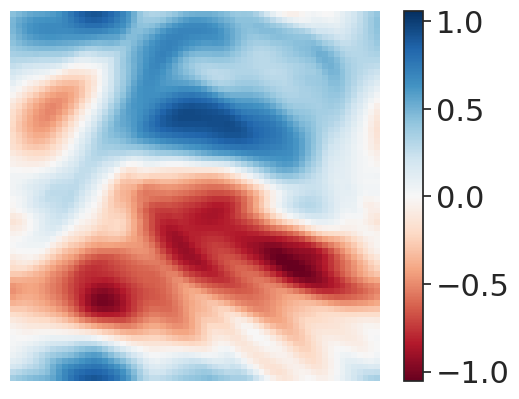

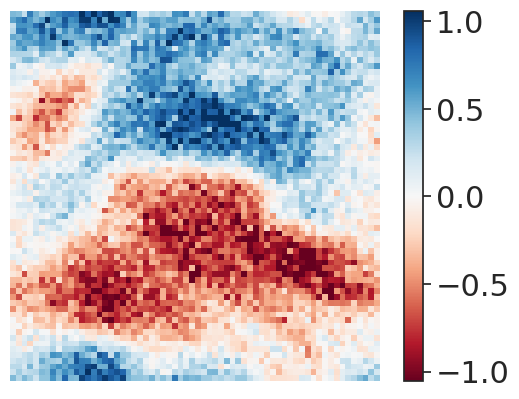

In [16]:
to_plot = [
    (('_true', 'TrueState'), dict(trajectory=true_state)),
    *cfgs.items(),
]
time = -1
value = 2
v_min = None
v_max = None
for _, v in to_plot:
    # _v_min = v['trajectory'][time, value].min()
    # _v_max = v['trajectory'][time, value].max()
    _v_min = np.quantile(v['trajectory'], .05)
    _v_max = np.quantile(v['trajectory'], .95)
    if v_min is None or v_min > _v_min:
        v_min = _v_min
    if v_max is None or v_max > _v_max:
        v_max = _v_max
for (alt_id, label), v in to_plot:
    fig_trajectory, ax = plt.subplots()
    traj = v['trajectory'][time, value]
    # imshow_out = ax.imshow(traj, cmap='RdBu', vmin=v_min, vmax=v_max)
    v_minimax = max(map(abs, (v_min, v_max)))
    imshow_out = ax.imshow(traj, cmap='RdBu', vmin=-v_minimax, vmax=v_minimax)
    ax.set_xlabel(label)
    ax.set_axis_off()
    print(label)
    fig_trajectory.savefig(f'Trajectory.{label}.{time}.{value}.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)
    fig_trajectory.colorbar(imshow_out, ax=ax)
    # ax.remove()
    # fig_trajectory.savefig(f'Trajectory.colorbar.{time}.{value}.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)

In [ ]:
to_plot = [
    *cfgs.items(),
]
time = -1
value = 0
for (alt_id, label), v in to_plot:
    fig_error, ax = plt.subplots()
    traj = v['trajectory'][time, value]
    imshow_out = ax.imshow(traj, cmap='RdBu', vmin=-v_minimax, vmax=v_minimax)
    ax.set_xlabel(label)
    ax.set_axis_off()
    print(label)
    fig_error.savefig(f'Error.{label}.{time}.{value}.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)
    fig_error.colorbar(imshow_out, ax=ax)